<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-5-Thermodynamics/Untitled166.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **5-Number Summary Layer versus the Learned Feature Layer**

**Fixed statistical layer.**
We introduce a statistical layer consisting of 5 neurons that compute the quantities
$$
(m, M, q_1, q_2, q_3),
$$
namely the minimum, maximum, and the first, second (median), and third quartiles of the input vector. This layer provides a fixed, hand-crafted summary of the data. The resulting 5-dimensional representation is then passed through a sequence of standard neural network layers, followed by a softmax layer for classification. We use it first for the **MNIST** data and then for **CIFAR-10** dataset.

Epoch 1/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1400 - loss: 2.2629 - val_accuracy: 0.1506 - val_loss: 2.2498
Epoch 2/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1503 - loss: 2.2451 - val_accuracy: 0.1388 - val_loss: 2.2455
Epoch 3/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1506 - loss: 2.2408 - val_accuracy: 0.1215 - val_loss: 2.2485
Epoch 4/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1499 - loss: 2.2394 - val_accuracy: 0.1522 - val_loss: 2.2409
Epoch 5/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1535 - loss: 2.2369 - val_accuracy: 0.1516 - val_loss: 2.2409
Epoch 6/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1538 - loss: 2.2367 - val_accuracy: 0.1520 - val_loss: 2.2438
Epoch 7/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1528 - loss: 2.2368 - val_accuracy: 0.1520 - val_loss: 2.2396
Epoch 8/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1554 - loss: 2.2344 - val_accuracy: 0.

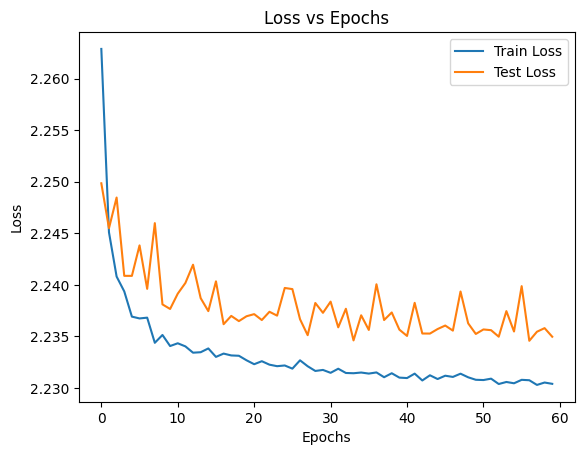

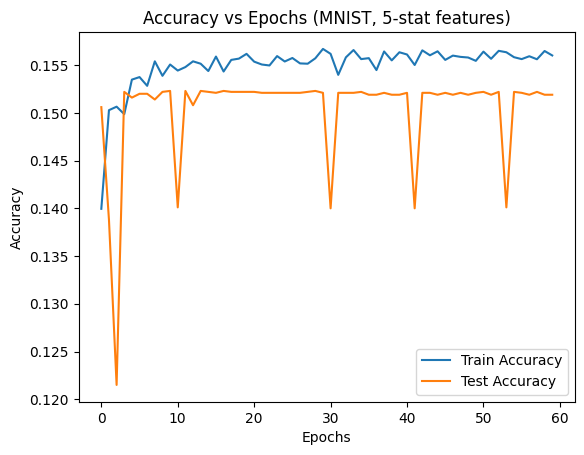

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# =========================
# 1. Load MNIST
# =========================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixels
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# =========================
# 2. Statistical feature map
# =========================
def extract_features(X):
    # X shape: (N, 28, 28)
    X_flat = X.reshape(X.shape[0], -1)

    m  = np.min(X_flat, axis=1, keepdims=True)
    M  = np.max(X_flat, axis=1, keepdims=True)
    q1 = np.percentile(X_flat, 25, axis=1).reshape(-1,1)
    q2 = np.percentile(X_flat, 50, axis=1).reshape(-1,1)
    q3 = np.percentile(X_flat, 75, axis=1).reshape(-1,1)

    return np.concatenate([m, M, q1, q2, q3], axis=1)

X_train_feat = extract_features(x_train)
X_test_feat  = extract_features(x_test)

# =========================
# 3. One-hot labels
# =========================
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

# =========================
# 4. Model
# =========================
model = keras.Sequential([
    layers.Input(shape=(5,)),      # (m, M, q1, q2, q3)
    layers.Dense(64, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 5. Training
# =========================
history = model.fit(
    X_train_feat, y_train_cat,
    validation_data=(X_test_feat, y_test_cat),
    epochs=60,
    batch_size=128,
    verbose=1
)

# =========================
# 6. Plot results
# =========================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs (MNIST, 5-stat features)')
plt.show()

Next we do the same thing for the CIFAR-10 dataset:

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1808 - loss: 2.2132 - val_accuracy: 0.1948 - val_loss: 2.1744
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2022 - loss: 2.1754 - val_accuracy: 0.2026 - val_loss: 2.1644
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2052 - loss: 2.1684 - val_accuracy: 0.2164 - val_loss: 2.1588
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2080 - loss: 2.1619 - val_accuracy: 0.2186 - val_loss: 2.1476
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2086 - loss: 2.1559 - val_accuracy: 0.2173 - val_loss: 2.1461
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2121 - loss: 2.1489 - val_accuracy: 0.2199 - val_loss: 2.1376
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2153 - loss: 2.1453 - val_accuracy: 0.2245 - val_loss: 2.1362
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 

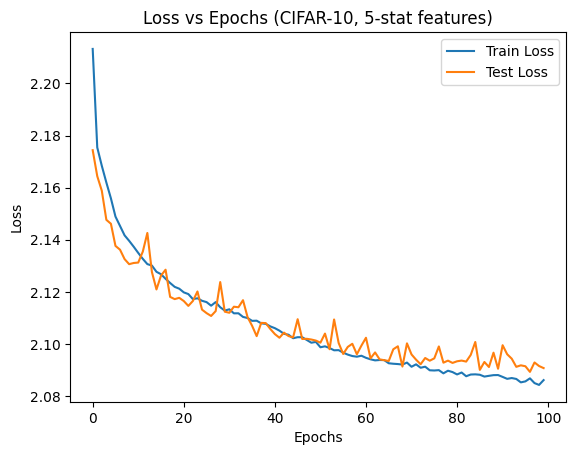

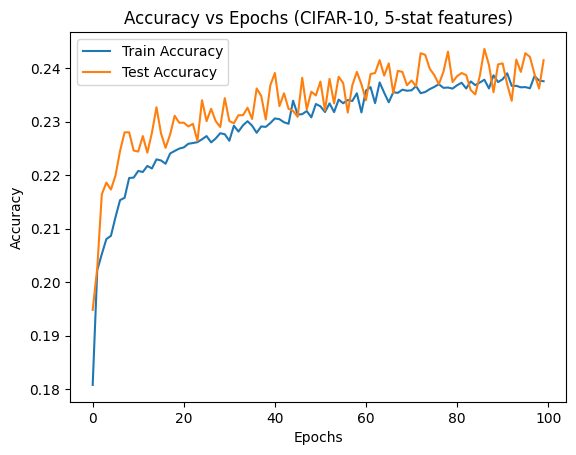

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# =========================
# 1. Load CIFAR-10
# =========================
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Flatten labels (CIFAR gives shape (N,1))
y_train = y_train.flatten()
y_test  = y_test.flatten()

# Normalize pixels
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# =========================
# 2. Statistical feature map
# =========================
def extract_features(X):
    # X shape: (N, 32, 32, 3)
    X_flat = X.reshape(X.shape[0], -1)   # (N, 3072)

    m  = np.min(X_flat, axis=1, keepdims=True)
    M  = np.max(X_flat, axis=1, keepdims=True)
    q1 = np.percentile(X_flat, 25, axis=1).reshape(-1,1)
    q2 = np.percentile(X_flat, 50, axis=1).reshape(-1,1)
    q3 = np.percentile(X_flat, 75, axis=1).reshape(-1,1)

    return np.concatenate([m, M, q1, q2, q3], axis=1)

X_train_feat = extract_features(x_train)
X_test_feat  = extract_features(x_test)

# =========================
# 3. One-hot labels
# =========================
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

# =========================
# 4. Model
# =========================
model = keras.Sequential([
    layers.Input(shape=(5,)),   # (m, M, q1, q2, q3)
    layers.Dense(64, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 5. Training
# =========================
history = model.fit(
    X_train_feat, y_train_cat,
    validation_data=(X_test_feat, y_test_cat),
    epochs=100,
    batch_size=128,
    verbose=1
)

# =========================
# 6. Plot results
# =========================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs (CIFAR-10, 5-stat features)')
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs (CIFAR-10, 5-stat features)')
plt.show()

The next code classifies MNIST, using all quantiles from 1\%  to 99\% as well as min and max as a fisrt layer with 101 neurons. The rest of the architecture contains 3 layers with 64 neurons and a softmax layer at the end.

Feature shape: (60000, 101)
Epoch 1/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2341 - loss: 2.0388 - val_accuracy: 0.2387 - val_loss: 2.0003
Epoch 2/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2617 - loss: 1.9658 - val_accuracy: 0.2747 - val_loss: 1.9127
Epoch 3/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2869 - loss: 1.8933 - val_accuracy: 0.2936 - val_loss: 1.8574
Epoch 4/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2965 - loss: 1.8638 - val_accuracy: 0.2929 - val_loss: 1.8469
Epoch 5/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2975 - loss: 1.8542 - val_accuracy: 0.2961 - val_loss: 1.8397
Epoch 6/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2984 - loss: 1.8481 - val_accuracy: 0.2908 - val_loss: 1.8407
Epoch 7/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3005 - loss: 1.8445 - val_accuracy: 0.2985 - val_loss: 1.8320
Epoch 8/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3015 - los

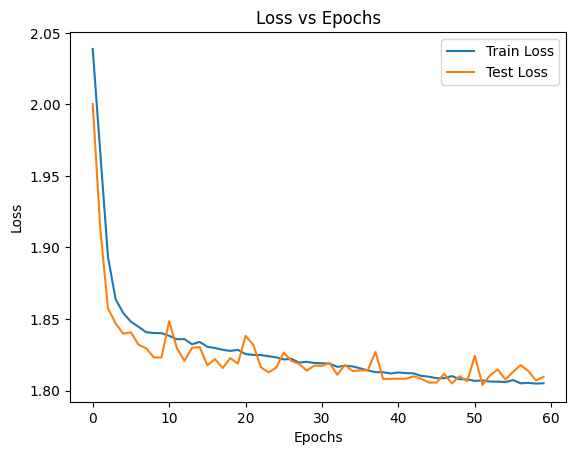

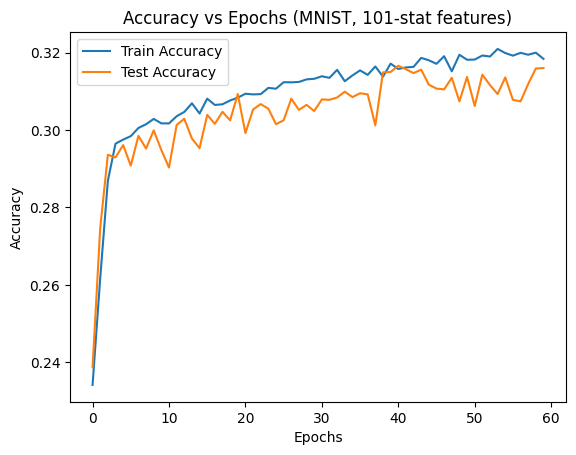

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# =========================
# 1. Load MNIST
# =========================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# =========================
# 2. Statistical feature map (100 quantiles)
# =========================
def extract_features(X):
    X_flat = X.reshape(X.shape[0], -1)

    # min and max
    m = np.min(X_flat, axis=1, keepdims=True)
    M = np.max(X_flat, axis=1, keepdims=True)

    # percentiles: 1%, 2%, ..., 99%
    quantile_levels = np.arange(1, 100)  # 1 to 99
    Q = np.percentile(X_flat, quantile_levels, axis=1).T  # shape (N, 99)

    return np.concatenate([m, M, Q], axis=1)

X_train_feat = extract_features(x_train)
X_test_feat  = extract_features(x_test)

print("Feature shape:", X_train_feat.shape)  # should be (60000, 101)

# =========================
# 3. One-hot labels
# =========================
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

# =========================
# 4. Model
# =========================
model = keras.Sequential([
    layers.Input(shape=(101,)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 5. Training
# =========================
history = model.fit(
    X_train_feat, y_train_cat,
    validation_data=(X_test_feat, y_test_cat),
    epochs=60,
    batch_size=128,
    verbose=1
)

# =========================
# 6. Plot results
# =========================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs (MNIST, 101-stat features)')
plt.show()

The next code classifies CIFAR-10, using all quantiles from 1\%  to 99\% as well as min and max as a fisrt layer with 101 neurons. The rest of the architecture contains 3 layers with 64 neurons and a softmax layer at the end.

Feature shape: (50000, 101)
Epoch 1/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1874 - loss: 2.1864 - val_accuracy: 0.1885 - val_loss: 2.1576
Epoch 2/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2051 - loss: 2.1493 - val_accuracy: 0.2213 - val_loss: 2.1292
Epoch 3/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2156 - loss: 2.1371 - val_accuracy: 0.2286 - val_loss: 2.1225
Epoch 4/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2169 - loss: 2.1313 - val_accuracy: 0.2208 - val_loss: 2.1211
Epoch 5/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2201 - loss: 2.1271 - val_accuracy: 0.2342 - val_loss: 2.1135
Epoch 6/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2211 - loss: 2.1226 - val_accuracy: 0.2216 - val_loss: 2.1198
Epoch 7/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2261 - loss: 2.1177 - val_accuracy: 0.2333 - val_loss: 2.1101
Epoch 8/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2250 - los

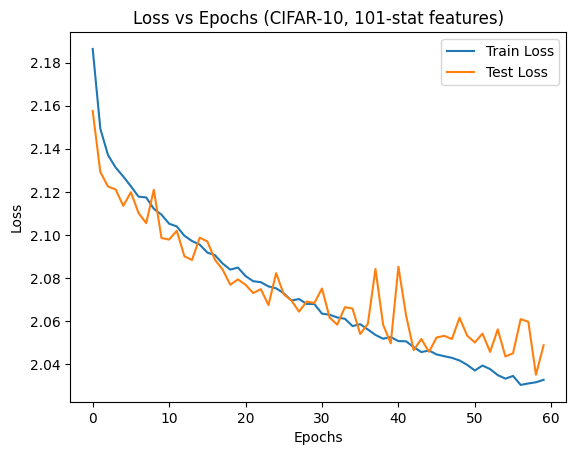

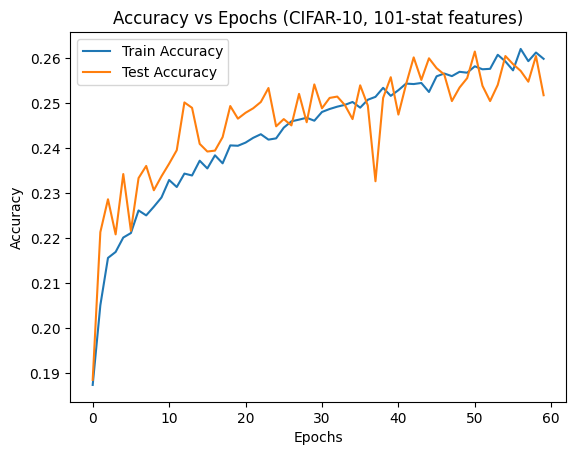

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# =========================
# 1. Load CIFAR-10
# =========================
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Flatten labels (shape (N,1) -> (N,))
y_train = y_train.flatten()
y_test  = y_test.flatten()

# Normalize pixels
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# =========================
# 2. Statistical feature map (100 quantiles)
# =========================
def extract_features(X):
    # X shape: (N, 32, 32, 3)
    X_flat = X.reshape(X.shape[0], -1)  # (N, 3072)

    # min and max
    m = np.min(X_flat, axis=1, keepdims=True)
    M = np.max(X_flat, axis=1, keepdims=True)

    # percentiles: 1%, ..., 99%
    quantile_levels = np.arange(1, 100)
    Q = np.percentile(X_flat, quantile_levels, axis=1).T  # (N, 99)

    return np.concatenate([m, M, Q], axis=1)

X_train_feat = extract_features(x_train)
X_test_feat  = extract_features(x_test)

print("Feature shape:", X_train_feat.shape)  # (50000, 101)

# =========================
# 3. One-hot labels
# =========================
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

# =========================
# 4. Model
# =========================
model = keras.Sequential([
    layers.Input(shape=(101,)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 5. Training
# =========================
history = model.fit(
    X_train_feat, y_train_cat,
    validation_data=(X_test_feat, y_test_cat),
    epochs=60,
    batch_size=128,
    verbose=1
)

# =========================
# 6. Plot results
# =========================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs (CIFAR-10, 101-stat features)')
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs (CIFAR-10, 101-stat features)')
plt.show()

**Learned feature layer for MNIST.**
Instead of prescribing the statistics, we introduce a shallow neural network with a 5-dimensional output, which plays the role of an encoder. This network learns a representation of each input image in terms of 5 features. The encoded output is then processed by the same subsequent layers as in above case, ending with a softmax classification layer.

Epoch 1/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8166 - loss: 0.6627 - val_accuracy: 0.9285 - val_loss: 0.2738
Epoch 2/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9390 - loss: 0.2262 - val_accuracy: 0.9448 - val_loss: 0.2040
Epoch 3/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9565 - loss: 0.1595 - val_accuracy: 0.9500 - val_loss: 0.1858
Epoch 4/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9647 - loss: 0.1269 - val_accuracy: 0.9531 - val_loss: 0.1652
Epoch 5/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9711 - loss: 0.1039 - val_accuracy: 0.9610 - val_loss: 0.1400
Epoch 6/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9755 - loss: 0.0878 - val_accuracy: 0.9628 - val_loss: 0.1386
Epoch 7/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9774 - loss: 0.0787 - val_accuracy: 0.9647 - val_loss: 0.1337
Epoch 8/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9814 - loss: 0.0659 - val_accuracy: 0.

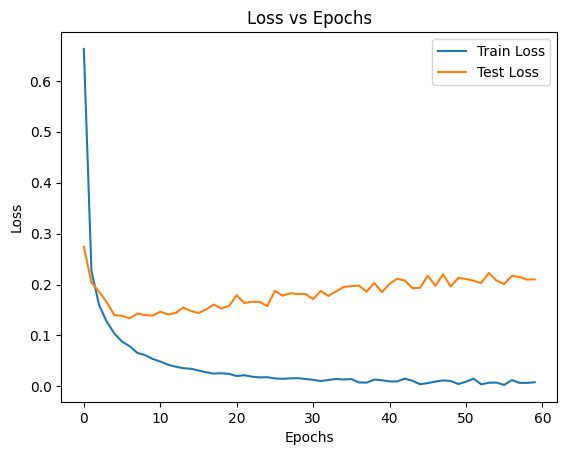

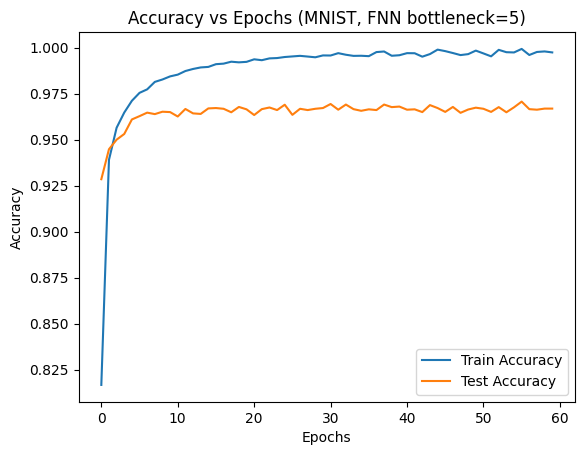

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# =========================
# 1. Load MNIST
# =========================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten images (28x28 → 784)
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

# =========================
# 2. One-hot labels
# =========================
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

# =========================
# 3. Model (FNN)
# =========================
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(14, activation='tanh'),
    layers.Dense(5, activation='tanh'),
    layers.Dense(14, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 4. Training
# =========================
history = model.fit(
    x_train, y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=60,
    batch_size=128,
    verbose=1
)

# =========================
# 5. Plot results
# =========================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs (MNIST, FNN bottleneck=5)')
plt.show()

**Learned feature layer for CIFAR-10.**
Instead of prescribing the statistics, we introduce a shallow neural network with a 5-dimensional output, which plays the role of an encoder. This network learns a representation of each input image in terms of 5 features. The encoded output is then processed by the same subsequent layers as in above case, ending with a softmax classification layer.

Epoch 1/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2392 - loss: 2.0290 - val_accuracy: 0.2723 - val_loss: 1.9432
Epoch 2/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2940 - loss: 1.9041 - val_accuracy: 0.3126 - val_loss: 1.8601
Epoch 3/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3240 - loss: 1.8415 - val_accuracy: 0.3512 - val_loss: 1.8024
Epoch 4/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3430 - loss: 1.8030 - val_accuracy: 0.3450 - val_loss: 1.7961
Epoch 5/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3524 - loss: 1.7785 - val_accuracy: 0.3420 - val_loss: 1.7907
Epoch 6/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3572 - loss: 1.7644 - val_accuracy: 0.3589 - val_loss: 1.7553
Epoch 7/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3653 - loss: 1.7440 - val_accuracy: 0.3574 - val_loss: 1.7482
Epoch 8/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3668 - loss: 1.7382 - val_accuracy: 0

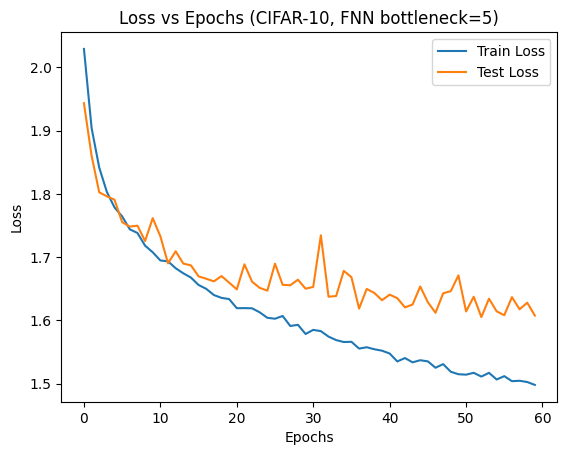

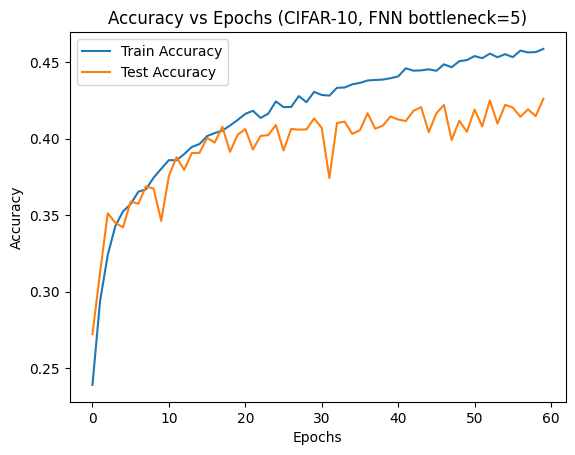

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# =========================
# 1. Load CIFAR-10
# =========================
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Flatten labels (shape (N,1) → (N,))
y_train = y_train.flatten()
y_test  = y_test.flatten()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten images (32x32x3 → 3072)
x_train = x_train.reshape(-1, 3072)
x_test  = x_test.reshape(-1, 3072)

# =========================
# 2. One-hot labels
# =========================
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

# =========================
# 3. Model (FNN with bottleneck = 5)
# =========================
model = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(14, activation='tanh'),
    layers.Dense(5, activation='tanh'),   # bottleneck
    layers.Dense(14, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 4. Training
# =========================
history = model.fit(
    x_train, y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=60,
    batch_size=128,
    verbose=1
)

# =========================
# 5. Plot results
# =========================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs (CIFAR-10, FNN bottleneck=5)')
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs (CIFAR-10, FNN bottleneck=5)')
plt.show()

# **More experiments**

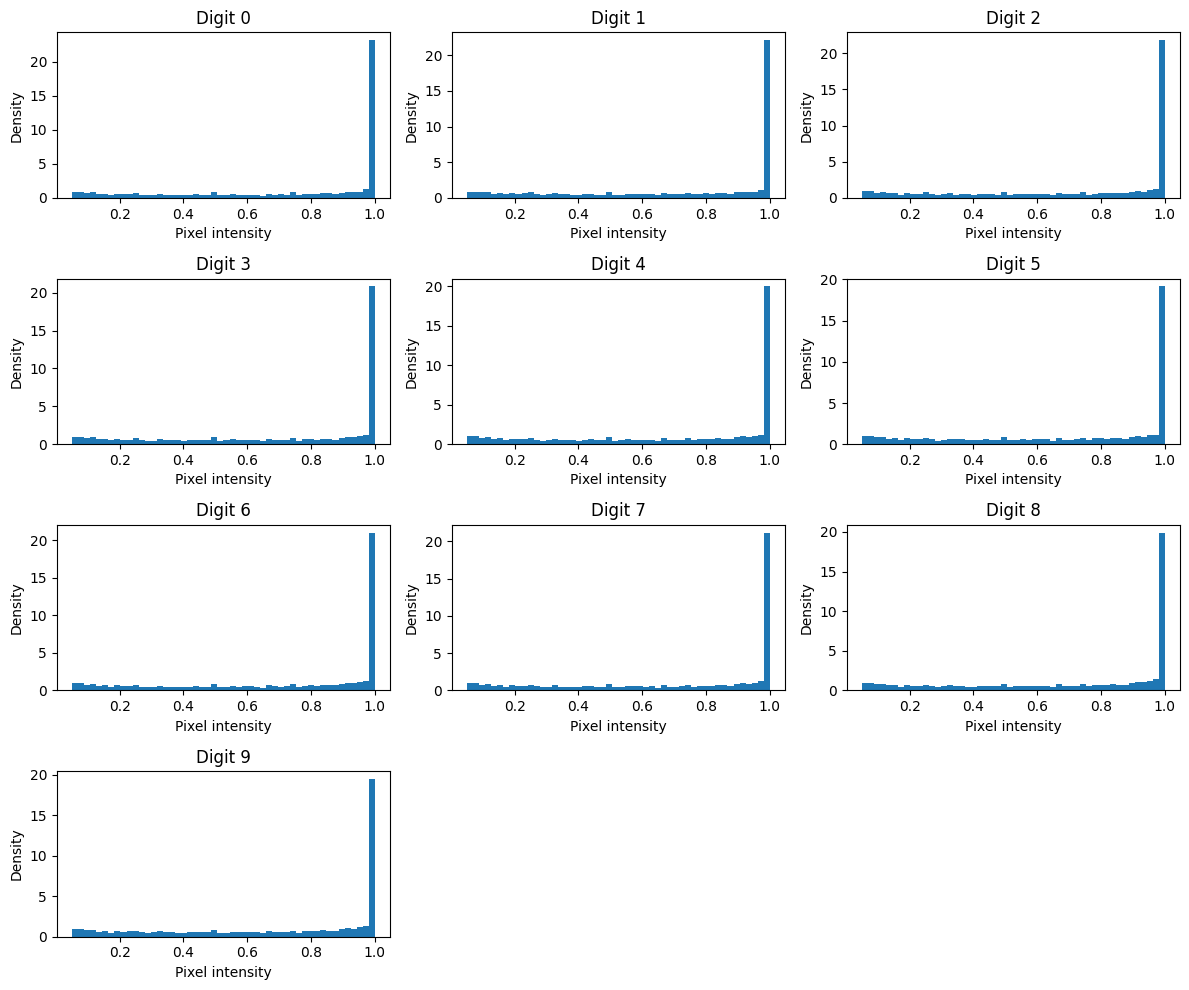

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# =========================
# 1. Load MNIST
# =========================
(x_train, y_train), _ = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0

# Flatten images
x_train = x_train.reshape(-1, 784)

# =========================
# 2. Plot histograms per digit
# =========================
plt.figure(figsize=(12, 10))

threshold = 0.05   # remove near-zero pixels

for digit in range(10):
    plt.subplot(4, 3, digit + 1)

    # select images of this digit
    Xd = x_train[y_train == digit]

    # flatten all pixels into one vector
    pixels = Xd.flatten()

    # remove near-zero values (background)
    pixels = pixels[pixels > threshold]

    # histogram
    plt.hist(pixels, bins=50, density=True)

    plt.title(f"Digit {digit}")
    plt.xlabel("Pixel intensity")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

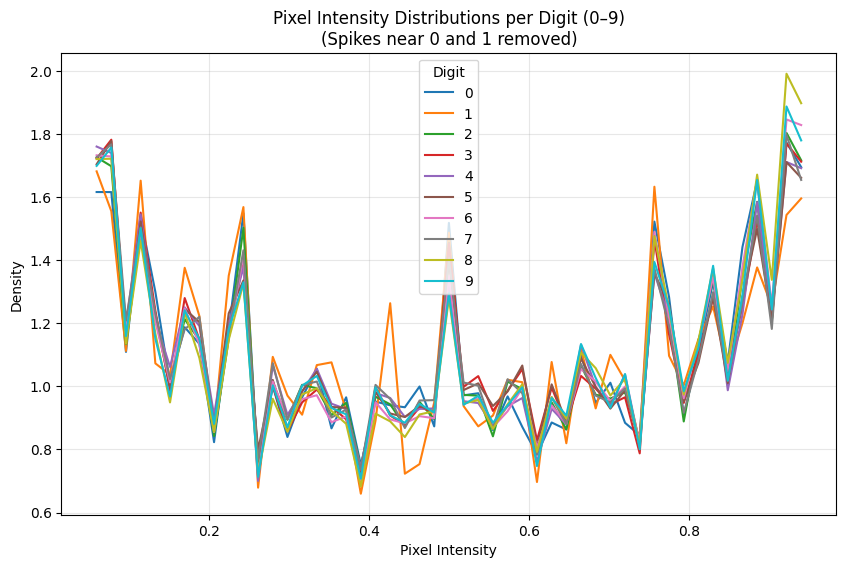

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# =========================
# 1. Load MNIST
# =========================
(x_train, y_train), _ = keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0

# Flatten images
X = x_train.reshape(len(x_train), -1)

# =========================
# 2. Remove spikes near 0 and 1
# =========================
# keep only mid-range intensities
mask = (X > 0.05) & (X < 0.95)

# =========================
# 3. Plot histograms per digit
# =========================
plt.figure(figsize=(10,6))

bins = np.linspace(0.05, 0.95, 50)

for digit in range(10):
    # select digit
    Xd = X[y_train == digit]

    # apply mask and flatten valid values
    vals = Xd[(Xd > 0.05) & (Xd < 0.95)]

    if len(vals) > 0:
        hist, edges = np.histogram(vals, bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])

        plt.plot(centers, hist, label=str(digit))

# =========================
# 4. Plot formatting
# =========================
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.title("Pixel Intensity Distributions per Digit (0–9)\n(Spikes near 0 and 1 removed)")
plt.legend(title="Digit")
plt.grid(alpha=0.3)

plt.show()

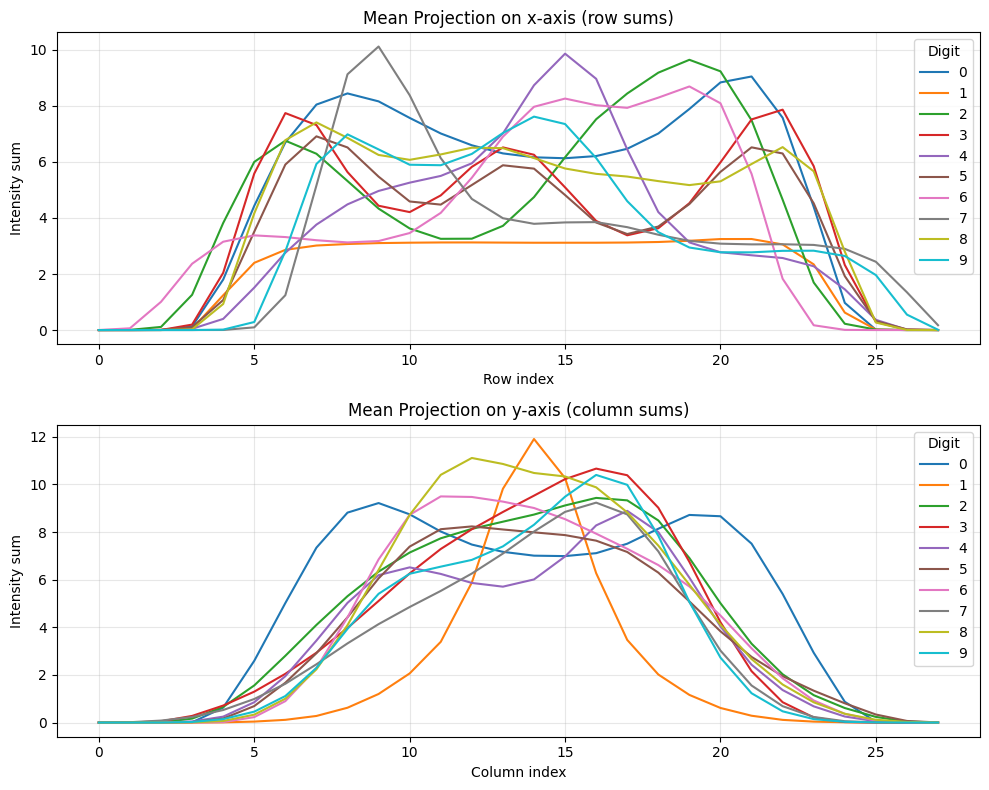

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# =========================
# 1. Load MNIST
# =========================
(x_train, y_train), _ = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0

# =========================
# 2. Compute projections
# =========================
# p_x: sum over columns → shape (N, 28)
p_x = np.sum(x_train, axis=2)

# p_y: sum over rows → shape (N, 28)
p_y = np.sum(x_train, axis=1)

# =========================
# 3. Plot projections per class
# =========================
fig, axes = plt.subplots(2, 1, figsize=(10,8))

for digit in range(10):
    px_mean = p_x[y_train == digit].mean(axis=0)
    py_mean = p_y[y_train == digit].mean(axis=0)

    axes[0].plot(px_mean, label=str(digit))
    axes[1].plot(py_mean, label=str(digit))

# =========================
# 4. Formatting
# =========================
axes[0].set_title("Mean Projection on x-axis (row sums)")
axes[0].set_xlabel("Row index")
axes[0].set_ylabel("Intensity sum")
axes[0].legend(title="Digit")
axes[0].grid(alpha=0.3)

axes[1].set_title("Mean Projection on y-axis (column sums)")
axes[1].set_xlabel("Column index")
axes[1].set_ylabel("Intensity sum")
axes[1].legend(title="Digit")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

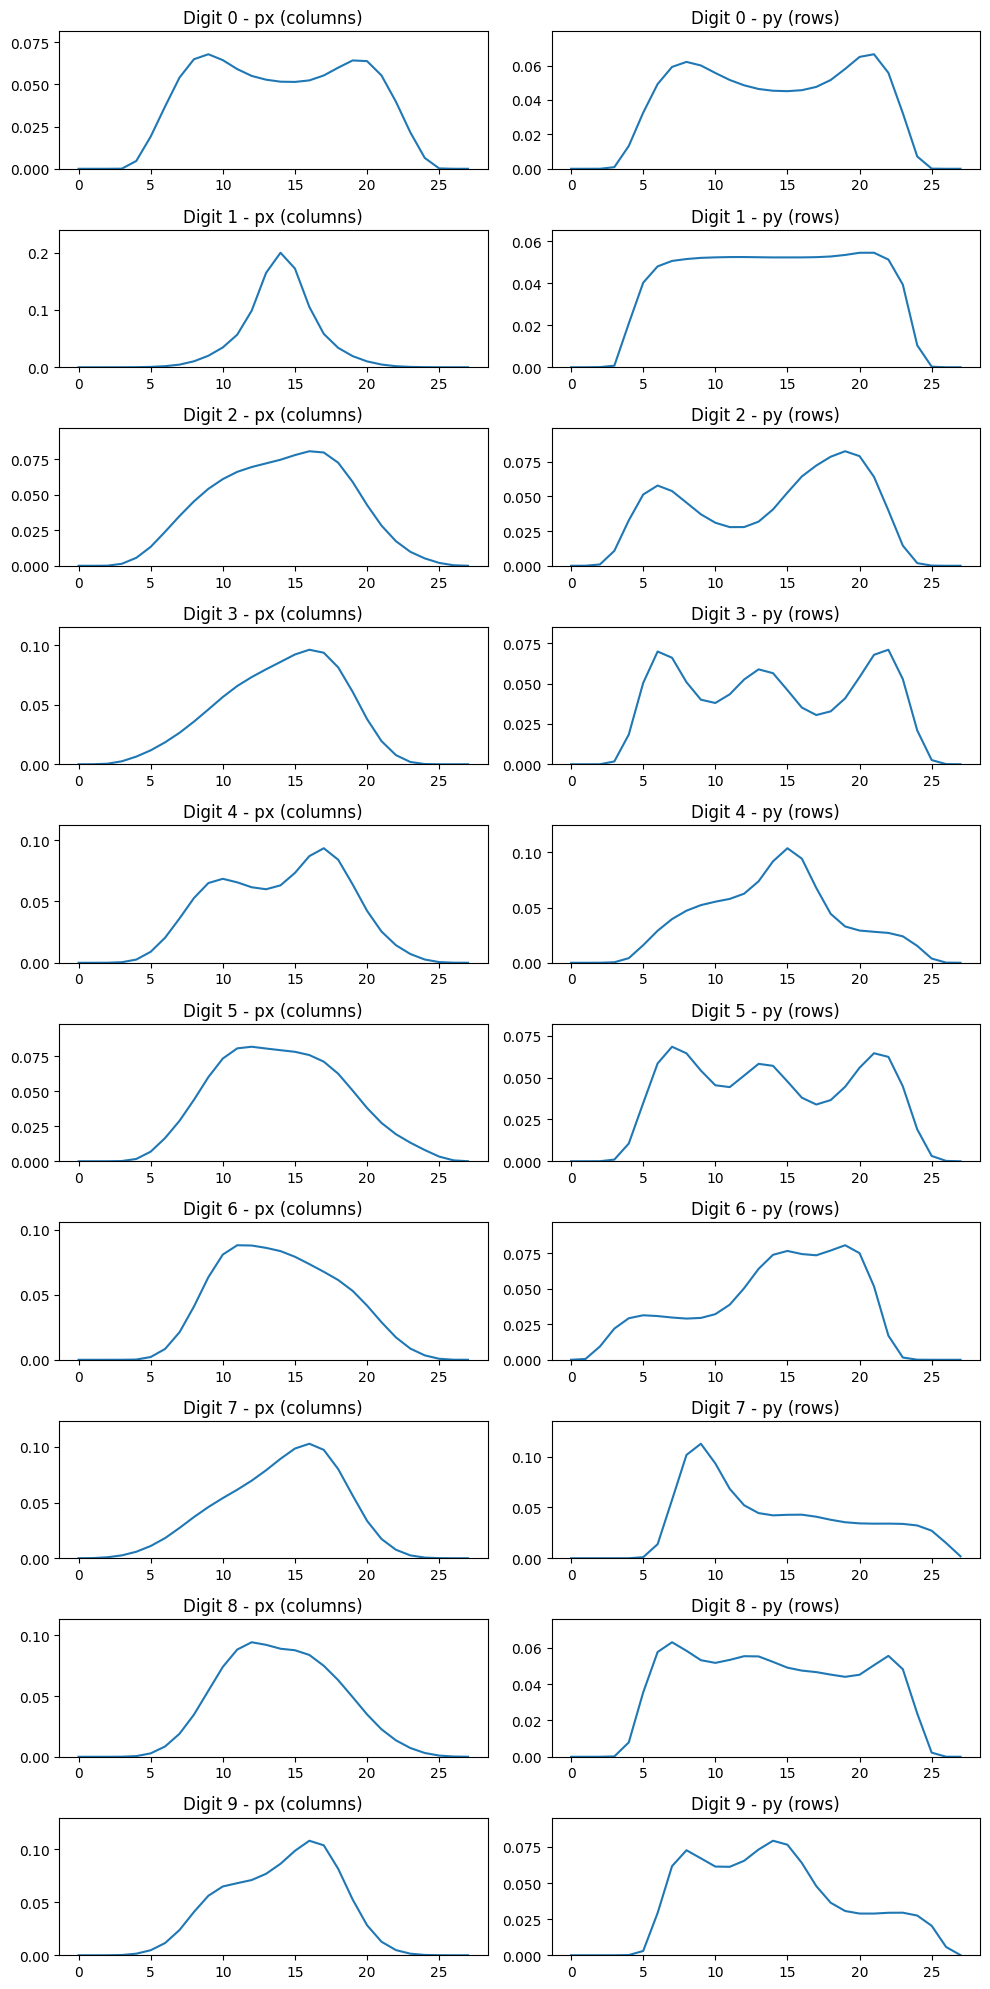

Mutual Information I(X;Y) per digit:
Digit 0: 0.2091
Digit 1: 0.2486
Digit 2: 0.0752
Digit 3: 0.1040
Digit 4: 0.0929
Digit 5: 0.1051
Digit 6: 0.0823
Digit 7: 0.1592
Digit 8: 0.0796
Digit 9: 0.0868


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# =========================
# 1. Load MNIST
# =========================
(x_train, y_train), _ = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0

# =========================
# 2. Functions
# =========================
def compute_projections(images):
    """
    images: (N, 28, 28)
    returns:
        px: (28,) marginal along x (columns)
        py: (28,) marginal along y (rows)
        pxy: (28,28) joint distribution
    """
    # sum over all images
    joint = np.sum(images, axis=0)  # shape (28,28)

    # normalize to probability
    pxy = joint / np.sum(joint)

    # marginals
    px = np.sum(pxy, axis=0)  # columns
    py = np.sum(pxy, axis=1)  # rows

    return px, py, pxy


def mutual_information(px, py, pxy):
    eps = 1e-12
    px_py = np.outer(py, px)

    mask = pxy > 0
    return np.sum(pxy[mask] * np.log(pxy[mask] / (px_py[mask] + eps)))


# =========================
# 3. Compute per digit
# =========================
MI_values = []

fig, axes = plt.subplots(10, 2, figsize=(10, 20))

for digit in range(10):
    imgs = x_train[y_train == digit]

    px, py, pxy = compute_projections(imgs)
    I = mutual_information(px, py, pxy)
    MI_values.append(I)

    # ---- Plot px ----
    axes[digit, 0].plot(px)
    axes[digit, 0].set_title(f"Digit {digit} - px (columns)")
    axes[digit, 0].set_ylim([0, px.max()*1.2])

    # ---- Plot py ----
    axes[digit, 1].plot(py)
    axes[digit, 1].set_title(f"Digit {digit} - py (rows)")
    axes[digit, 1].set_ylim([0, py.max()*1.2])

plt.tight_layout()
plt.show()

# =========================
# 4. Print Mutual Information
# =========================
print("Mutual Information I(X;Y) per digit:")
for d, val in enumerate(MI_values):
    print(f"Digit {d}: {val:.4f}")

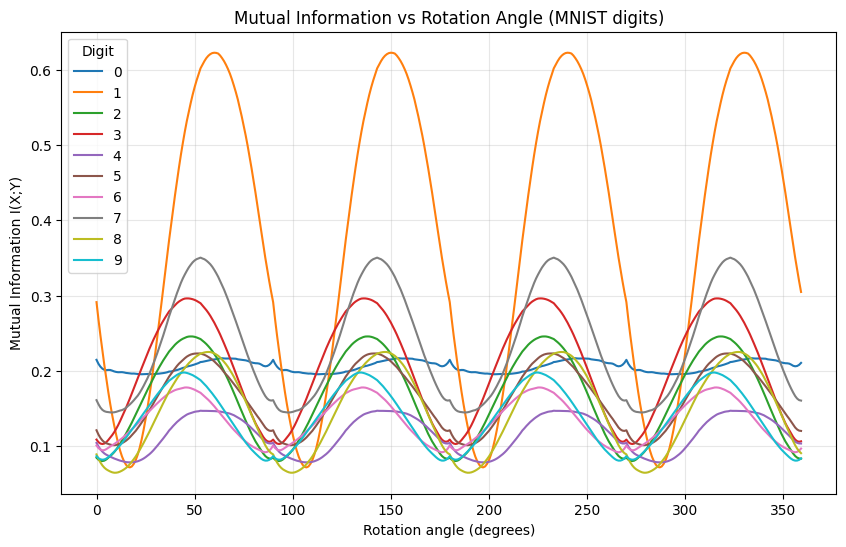

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from scipy.ndimage import rotate

# =========================
# 1. Load MNIST
# =========================
(x_train, y_train), _ = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0

# =========================
# 2. Functions
# =========================
def compute_joint(images):
    joint = np.sum(images, axis=0)
    pxy = joint / np.sum(joint)
    px = np.sum(pxy, axis=0)
    py = np.sum(pxy, axis=1)
    return px, py, pxy


def mutual_information(px, py, pxy):
    eps = 1e-12
    px_py = np.outer(py, px)
    mask = pxy > 0
    return np.sum(pxy[mask] * np.log(pxy[mask] / (px_py[mask] + eps)))


def rotate_batch(images, angle):
    return np.array([
        rotate(img, angle, reshape=False, order=1, mode='constant', cval=0.0)
        for img in images
    ])


# =========================
# 3. Parameters
# =========================
angles = np.arange(0, 360, 1)
samples_per_class = 1000

MI_curves = {}

# =========================
# 4. Loop over digits
# =========================
for digit in range(10):
    imgs = x_train[y_train == digit][:samples_per_class]

    MI_vals = []

    for theta in angles:
        rotated_imgs = rotate_batch(imgs, theta)

        px, py, pxy = compute_joint(rotated_imgs)
        I = mutual_information(px, py, pxy)

        MI_vals.append(I)

    MI_curves[digit] = np.array(MI_vals)

# =========================
# 5. Plot curves
# =========================
plt.figure(figsize=(10,6))

for digit in range(10):
    plt.plot(angles, MI_curves[digit], label=str(digit))

plt.xlabel("Rotation angle (degrees)")
plt.ylabel("Mutual Information I(X;Y)")
plt.title("Mutual Information vs Rotation Angle (MNIST digits)")
plt.legend(title="Digit")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import numpy as np
from tensorflow import keras
from scipy.ndimage import rotate
import matplotlib.pyplot as plt

# =========================
# 1. Load MNIST
# =========================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# =========================
# 2. Parameters
# =========================
angles = np.arange(0, 360, 5)   # 72 points
eps = 1e-12

# =========================
# 3. Core functions
# =========================
def compute_joint(img):
    pxy = img / (np.sum(img) + eps)
    px = np.sum(pxy, axis=0)
    py = np.sum(pxy, axis=1)
    return px, py, pxy


def mutual_information(px, py, pxy):
    px_py = np.outer(py, px)
    mask = pxy > 0
    return np.sum(pxy[mask] * np.log(pxy[mask] / (px_py[mask] + eps)))


def MI_curve(img):
    curve = []
    for theta in angles:
        r = rotate(img, theta, reshape=False, order=1, mode='constant', cval=0.0)
        px, py, pxy = compute_joint(r)
        curve.append(mutual_information(px, py, pxy))
    return np.array(curve)


# =========================
# 4. Build prototype curves
# =========================
print("Computing class prototypes...")

prototypes = {}

samples_per_class = 500

for d in range(10):
    imgs = x_train[y_train == d][:samples_per_class]

    curves = []
    for img in imgs:
        curves.append(MI_curve(img))

    prototypes[d] = np.mean(curves, axis=0)

# =========================
# 5. Classification
# =========================
def classify(img):
    curve = MI_curve(img)

    distances = []
    for d in range(10):
        dist = np.linalg.norm(curve - prototypes[d])
        distances.append(dist)

    return np.argmin(distances)


# =========================
# 6. Evaluate
# =========================
print("Evaluating...")

N_test = 2000  # keep manageable
correct = 0

for i in range(N_test):
    pred = classify(x_test[i])
    if pred == y_test[i]:
        correct += 1

accuracy = correct / N_test
print(f"Accuracy: {accuracy:.4f}")

Computing class prototypes...
Evaluating...
Accuracy: 0.2190
